In [4]:
import itertools
import pandas as pd

url = f'https://drive.google.com/uc?export=download&id=1xJZO4bt5VZf4Ix-w-QPGMVpPxjlCQac3'
base = pd.read_excel(url)

#base = pd.read_excel(r"C:\Users\C023525\Downloads\base_compras_informatica.xlsx")
#base = base[(base["col1"] in ["valor1","valor2"]) and (base["col2"] in ["valor1","valor2"])].reset_index()

valores = base['valor'].tolist()
valor_esperado = 5063.69

valores_int = [int(round(v * 100)) for v in valores]
valor_esperado_int = int(round(valor_esperado * 100))
total_int = sum(valores_int)
n = len(valores_int)
combinacoes_possiveis = 2**len(valores) - 1 - len(valores)

print("Total:", total_int / 100)
print("Valor Esperado:", valor_esperado)
print("Total Combinações Possíveis:", combinacoes_possiveis)

meio = n // 2
esquerda = list(range(meio))
direita = list(range(meio, n))

mapa = {}
for r in range(len(esquerda) + 1):
    for combo in itertools.combinations(esquerda, r):
        s = sum(valores_int[i] for i in combo)
        mapa.setdefault(s, []).append(combo)

solucoes = []
parar = False
for r in range(len(direita) + 1):
    for combo_dir in itertools.combinations(direita, r):
        s = sum(valores_int[i] for i in combo_dir)
        faltando = valor_esperado_int - s
        if faltando in mapa:
            for combo_esq in mapa[faltando]:
                solucao = [0] * n
                for i in combo_esq:
                    solucao[i] = 1
                for i in combo_dir:
                    solucao[i] = 1
                solucoes.append(solucao)
                if len(solucoes) >= combinacoes_possiveis:
                    parar = True
                    break
        if parar:
            break
    if parar:
        break

txt = "solução encontrada" if len(solucoes) == 1 else "soluções encontradas"

print(f"\n{len(solucoes)} {txt}:\n")
for idx, solucao in enumerate(solucoes):

    indices_mantidos = [i for i in range(len(valores)) if solucao[i] == 1]

    mantidos = [(i, valores[i]) for i in indices_mantidos]
    base_mantida = base.loc[indices_mantidos]
    print(f"Solução {idx + 1}")

    for i, valor in mantidos:
        print(f"manter {valor} | índice {i}")
    print("\nCategoria:", base_mantida['categoria'].unique())
    print("\nData:", base_mantida['data_compra'].unique())
    print("\nVendedor:", base_mantida['vendedor'].unique())

    print("\nProduto:", base_mantida['produto'].unique())
    print("\nCliente:", base_mantida['tipo_cliente'].unique())
    print("\nValores únicos por coluna:")
    for col in ['categoria','produto','data_compra','vendedor','tipo_cliente']:
        print(f"{col}: {base_mantida[col].nunique()}")
    print("-" * 40)


Total: 16842.65
Valor Esperado: 5063.69
Total Combinações Possíveis: 268435427

92 soluções encontradas:

Solução 1
manter 703.13 | índice 0
manter 110.33 | índice 1
manter 749.95 | índice 4
manter 791.47 | índice 5
manter 487.73 | índice 10
manter 982.29 | índice 12
manter 815.94 | índice 13
manter 422.85 | índice 15

Categoria: ['Moda' 'Casa' 'Eletrônicos' 'Esportes']

Data: ['abr/25' 'abr/26' 'fev/26' 'jan/25' 'junho/26' 'mai/25' 'mai/26']

Vendedor: ['Carlos Oliveira' 'João Silva' 'Maria Souza']

Produto: ['Camiseta' 'Sofá' 'Celular' 'Notebook' 'Panela' 'Esteira' 'Tablet']

Cliente: ['Novo' 'Recorrente']

Valores únicos por coluna:
categoria: 4
produto: 7
data_compra: 7
vendedor: 3
tipo_cliente: 2
----------------------------------------
Solução 2
manter 703.13 | índice 0
manter 110.33 | índice 1
manter 791.47 | índice 5
manter 487.73 | índice 10
manter 982.29 | índice 12
manter 815.94 | índice 13
manter 422.85 | índice 15
manter 749.95 | índice 26

Categoria: ['Moda' 'Casa' 'Eletr

In [5]:
import pandas as pd
from itertools import combinations
from collections import Counter

n_sol = len(solucoes)
colunas = ['vendedor', 'categoria', 'data_compra', 'produto', 'tipo_cliente']

print(f"Analisando {n_sol} soluções\n")
for col in colunas:
    print(f"=== {col} ===")
    freq = {}
    for solucao in solucoes:
        idx = [i for i in range(len(solucao)) if solucao[i] == 1]
        for valor in base.loc[idx, col].unique():
            freq[valor] = freq.get(valor, 0) + 1

    linhas = []
    for valor, qtd in freq.items():
        p = qtd / n_sol
        poder = 1 - 2 * abs(p - 0.5)
        linhas.append((valor, qtd, p, poder))

    linhas.sort(key=lambda x: -x[3])
    for valor, qtd, p, poder in linhas:
        tag = "discrimina" if poder > 0.6 else ("estrutural" if poder < 0.15 else "")
        print(f"  {str(valor):20s} {qtd:3d}/{n_sol} ({p:4.0%})  poder={poder:.2f} {tag}")
    print()

    cols = ['vendedor', 'categoria', 'data_compra', 'produto']  # tipo_cliente é sempre 2, fica de fora

# cardinalidade de cada coluna em cada solução
tamanhos = []
for solucao in solucoes:
    idx = [i for i in range(len(solucao)) if solucao[i] == 1]
    tamanhos.append({c: base.loc[idx, c].nunique() for c in cols})

n_sol = len(tamanhos)

# cardinalidades distintas por coluna
print("Cardinalidades distintas por coluna:")
distintas = {}
for c in cols:
    distintas[c] = sorted({t[c] for t in tamanhos})
    print(f"  {c:12s}: {distintas[c]}  -> {len(distintas[c])} tamanho(s)")

Analisando 92 soluções

=== vendedor ===
  Maria Souza           33/92 ( 36%)  poder=0.72 discrimina
  Carlos Oliveira       86/92 ( 93%)  poder=0.13 estrutural
  João Silva            92/92 (100%)  poder=0.00 estrutural

=== categoria ===
  Moda                  47/92 ( 51%)  poder=0.98 discrimina
  Esportes              68/92 ( 74%)  poder=0.52 
  Casa                  91/92 ( 99%)  poder=0.02 estrutural
  Eletrônicos           92/92 (100%)  poder=0.00 estrutural

=== data_compra ===
  mar/25                43/92 ( 47%)  poder=0.93 discrimina
  abr/26                54/92 ( 59%)  poder=0.83 discrimina
  jan/25                36/92 ( 39%)  poder=0.78 discrimina
  mai/25                56/92 ( 61%)  poder=0.78 discrimina
  abr/25                31/92 ( 34%)  poder=0.67 discrimina
  fev/26                27/92 ( 29%)  poder=0.59 
  fev/25                26/92 ( 28%)  poder=0.57 
  junho/26              75/92 ( 82%)  poder=0.37 
  jun/25                17/92 ( 18%)  poder=0.37 
  mai/26 

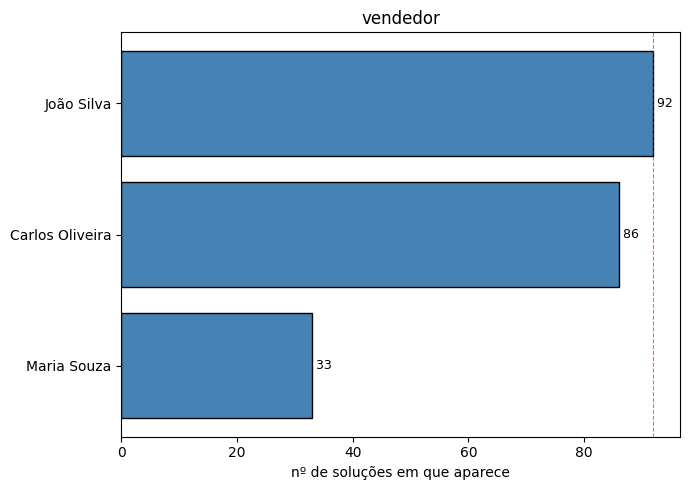

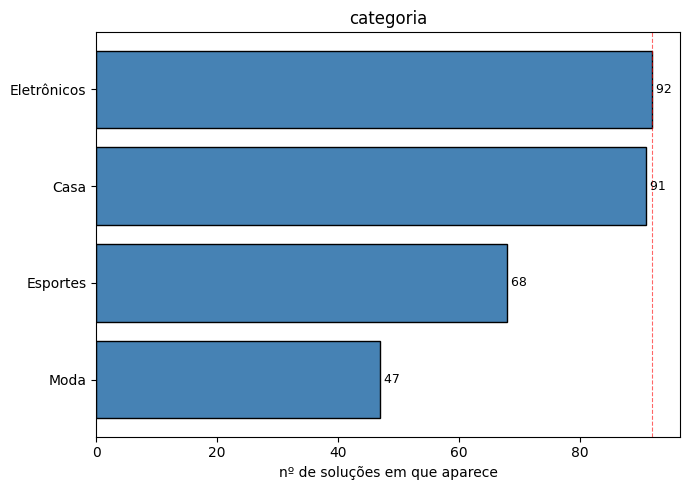

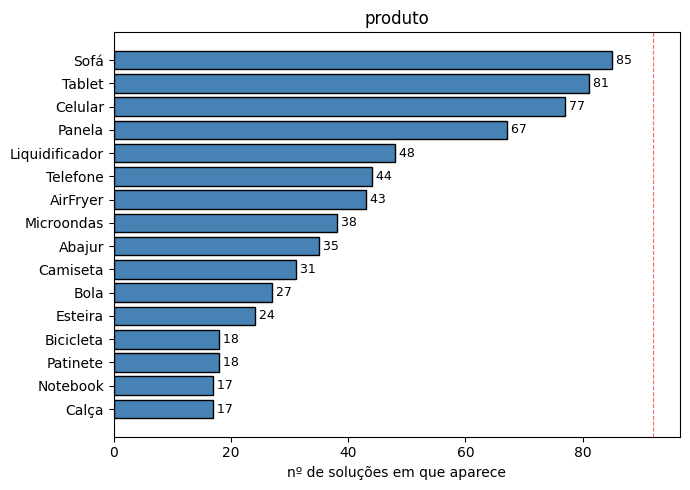

In [6]:
import matplotlib.pyplot as plt
from collections import Counter

def plotar_valores(*colunas):
    fig, axes = plt.subplots(1, len(colunas), figsize=(7 * len(colunas), 5))
    if len(colunas) == 1:
        axes = [axes]
    for ax, col in zip(axes, colunas):
        freq = Counter()
        for solucao in solucoes:
            idx = [i for i in range(len(solucao)) if solucao[i] == 1]
            for v in base.loc[idx, col].unique():
                freq[v] += 1
        itens = freq.most_common()                      # do mais frequente ao menos
        nomes = [str(k) for k, _ in itens]
        vals  = [v for _, v in itens]
        ax.barh(nomes, vals, color='steelblue', edgecolor='black')
        ax.invert_yaxis()                               # maior no topo
        for i, v in enumerate(vals):
            ax.text(v, i, f' {v}', va='center', fontsize=9)
        ax.axvline(len(solucoes), color='red', ls='--', lw=0.8, alpha=0.6)  # linha do total
        ax.set_xlabel('nº de soluções em que aparece')
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

plotar_valores('vendedor')                          # Todos os vendedores
plotar_valores('categoria')                         # Todas as categoria
plotar_valores('produto')                           # Todos os produtos


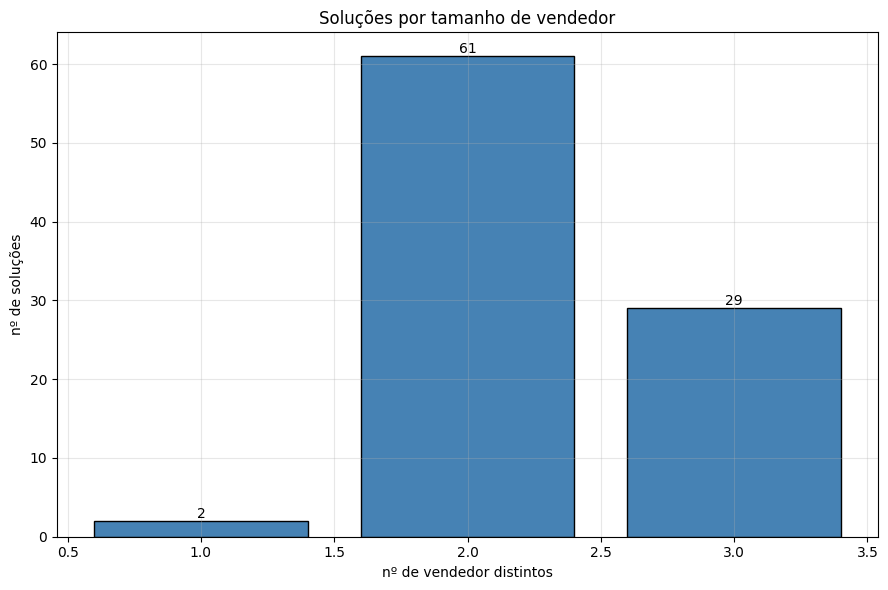

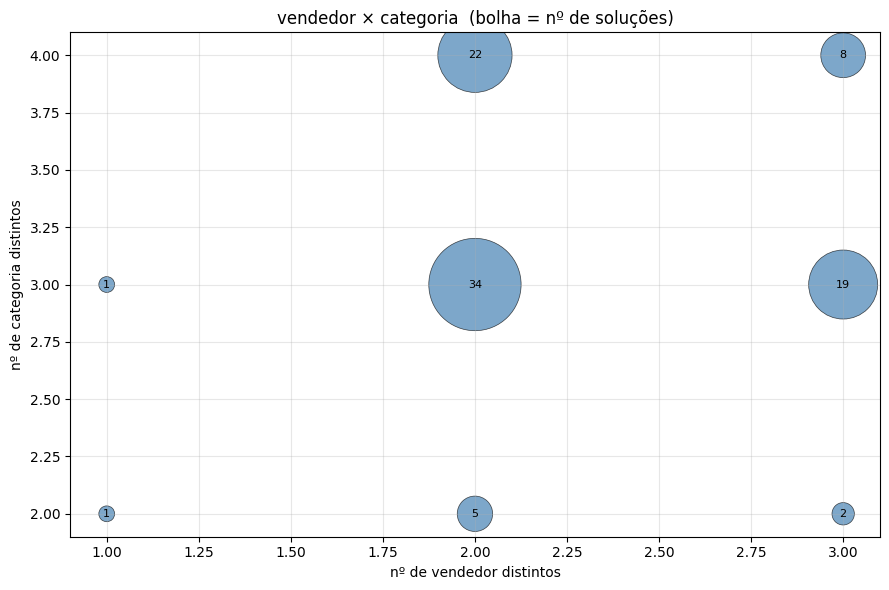

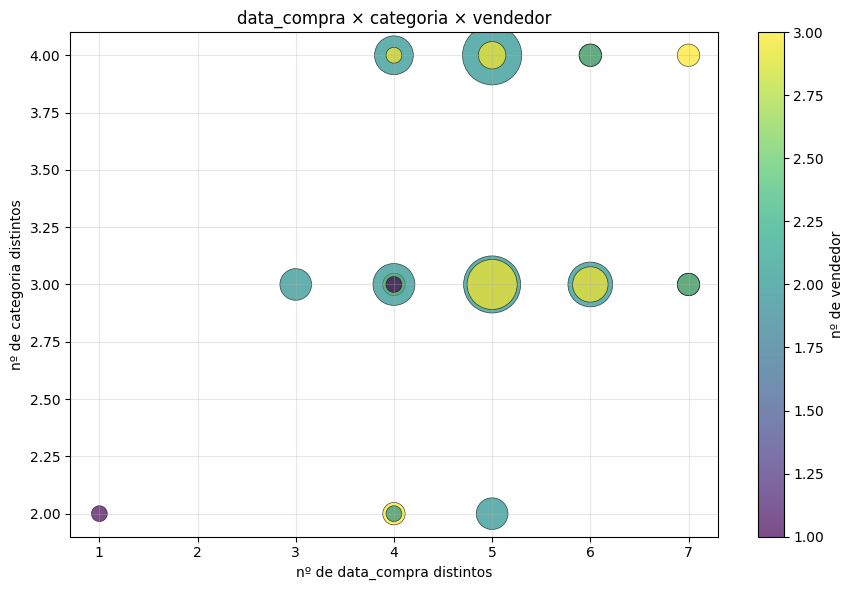

In [7]:
import matplotlib.pyplot as plt
from collections import Counter

def plotar(*colunas):
    # cardinalidade de cada coluna pedida, por solução
    dados = []
    for solucao in solucoes:
        idx = [i for i in range(len(solucao)) if solucao[i] == 1]
        dados.append(tuple(base.loc[idx, c].nunique() for c in colunas))
    grupos = Counter(dados)

    plt.figure(figsize=(9, 6))

    if len(colunas) == 1:                      # === 1 coluna: barras ===
        itens = sorted(grupos.items())
        xs = [k[0] for k, _ in itens]
        ys = [v for _, v in itens]
        plt.bar(xs, ys, color='steelblue', edgecolor='black')
        for x, y in zip(xs, ys):
            plt.text(x, y, str(y), ha='center', va='bottom')
        plt.xlabel(f'nº de {colunas[0]} distintos')
        plt.ylabel('nº de soluções')
        plt.title(f'Soluções por tamanho de {colunas[0]}')

    elif len(colunas) == 2:                    # === 2 colunas: bolhas ===
        xs = [g[0] for g in grupos]; ys = [g[1] for g in grupos]
        tams = [grupos[g] * 130 for g in grupos]
        plt.scatter(xs, ys, s=tams, c='steelblue', alpha=0.7,
                    edgecolors='black', linewidths=0.5)
        for g in grupos:
            plt.text(g[0], g[1], str(grupos[g]), ha='center', va='center', fontsize=8)
        plt.xlabel(f'nº de {colunas[0]} distintos')
        plt.ylabel(f'nº de {colunas[1]} distintos')
        plt.title(f'{colunas[0]} × {colunas[1]}  (bolha = nº de soluções)')

    elif len(colunas) == 3:                    # === 3 colunas: bolhas + cor ===
        xs = [g[0] for g in grupos]; ys = [g[1] for g in grupos]
        cors = [g[2] for g in grupos]; tams = [grupos[g] * 130 for g in grupos]
        sc = plt.scatter(xs, ys, s=tams, c=cors, cmap='viridis',
                         alpha=0.7, edgecolors='black', linewidths=0.5)
        plt.colorbar(sc, label=f'nº de {colunas[2]}')
        plt.xlabel(f'nº de {colunas[0]} distintos')
        plt.ylabel(f'nº de {colunas[1]} distintos')
        plt.title(f'{colunas[0]} × {colunas[1]} × {colunas[2]}')

    else:
        print("Escolha 1, 2 ou 3 colunas."); return

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plotar('vendedor')
plotar('vendedor', 'categoria')
plotar('data_compra', 'categoria', 'vendedor')


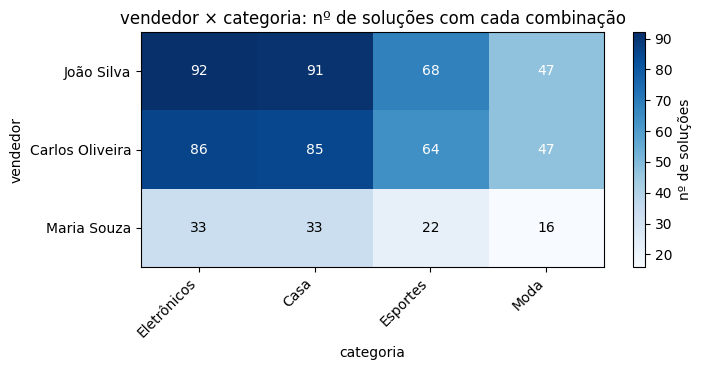

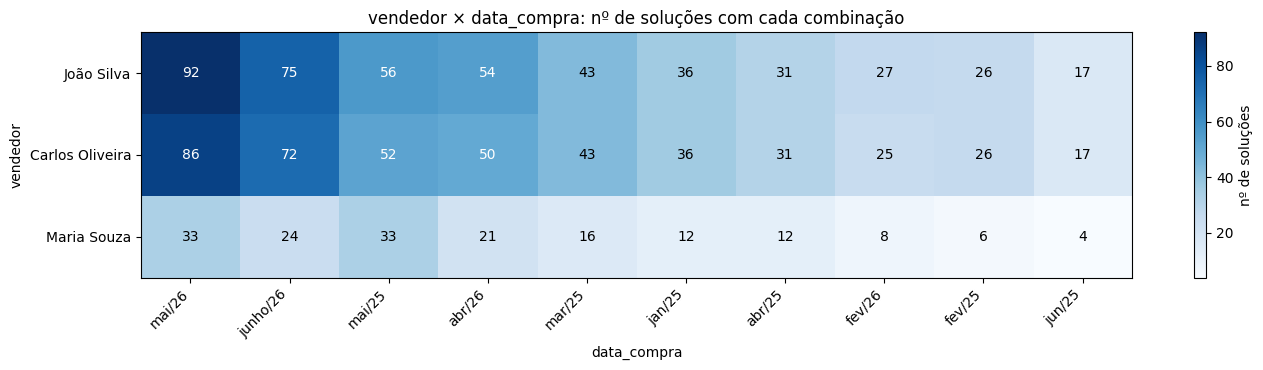

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from itertools import product

def plotar_combinacoes(col_a, col_b):
    freq_a, freq_b, pares = Counter(), Counter(), Counter()
    for solucao in solucoes:
        idx = [i for i in range(len(solucao)) if solucao[i] == 1]
        va = list(base.loc[idx, col_a].unique())
        vb = list(base.loc[idx, col_b].unique())
        for a in va: freq_a[a] += 1
        for b in vb: freq_b[b] += 1
        for a, b in product(va, vb):
            pares[(a, b)] += 1

    linhas = [k for k, _ in freq_a.most_common()]   # mais frequentes primeiro
    colunas = [k for k, _ in freq_b.most_common()]
    M = np.zeros((len(linhas), len(colunas)), dtype=int)
    for i, a in enumerate(linhas):
        for j, b in enumerate(colunas):
            M[i, j] = pares.get((a, b), 0)

    fig, ax = plt.subplots(figsize=(1.1 * len(colunas) + 3, 0.6 * len(linhas) + 2))
    im = ax.imshow(M, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(colunas))); ax.set_xticklabels(colunas, rotation=45, ha='right')
    ax.set_yticks(range(len(linhas)));  ax.set_yticklabels(linhas)
    for i in range(len(linhas)):
        for j in range(len(colunas)):
            ax.text(j, i, M[i, j], ha='center', va='center',
                    color='white' if M[i, j] > M.max() / 2 else 'black')
    ax.set_xlabel(col_b); ax.set_ylabel(col_a)
    ax.set_title(f'{col_a} × {col_b}: nº de soluções com cada combinação')
    plt.colorbar(im, label='nº de soluções')
    plt.tight_layout(); plt.show()

plotar_combinacoes('vendedor', 'categoria')
plotar_combinacoes('vendedor', 'data_compra')

In [9]:
import pandas as pd
from itertools import combinations

n_sol = len(solucoes)
cols = ['vendedor', 'categoria', 'data_compra', 'tipo_cliente', 'produto']

perfis = []
for solucao in solucoes:
    idx = [i for i in range(len(solucao)) if solucao[i] == 1]
    perfil = {col: frozenset(base.loc[idx, col].unique()) for col in cols}
    perfil['_n_itens'] = len(idx)
    perfis.append(perfil)

print(f"{n_sol} soluções enumeradas.\n")

print("=== Soluções mais concentradas (poucos valores distintos) ===")
def concentracao(p):
    return sum(len(p[c]) for c in cols)   # soma de cardinalidades
ranking = sorted(range(n_sol), key=lambda k: concentracao(perfis[k]))
for k in ranking[:5]:
    p = perfis[k]
    resumo = ", ".join(f"{c}={len(p[c])}" for c in cols)
    print(f"  Solução {k+1}: {resumo}")

print("\n=== Combinações (coluna × valor) mais raras entre as soluções ===")
from collections import Counter
par_freq = Counter()
for p in perfis:
    for c1, c2, c3, c4 in combinations(cols, 4):
        for v1 in p[c1]:
            for v2 in p[c2]:
                for v3 in p[c3]:
                    for v4 in p[c4]:
                        par_freq[(c1, v1, c2, v2, c3, v3, c4, v4)] += 1
raros = sorted(par_freq.items(), key=lambda x: x[1])
for (c1, v1, c2, v2, c3, v3, c4, v4), q in raros[:10]:
    print(f"  {v1} ({c1}) + {v2} ({c2}) + {v3} ({c3}) + {v4} ({c4}): {q}/{n_sol} soluções")

print("")

PISTAS = {}

def add_pista(*args):
    if len(args) == 1 and isinstance(args[0][0], (list, tuple)):
        pistas = args[0]            # add_pista([p1, p2, ...])  -> lista de pistas
    elif len(args) == 1:
        pistas = [args[0]]          # add_pista([nome, col, regra]) -> uma pista
    else:
        pistas = [args]             # add_pista(nome, col, regra)   -> uma pista (3 soltos)

    for nome, coluna, regra in pistas:
        PISTAS[nome] = (coluna, regra)
        print(f"pista '{nome}' adicionada (coluna: {coluna}).")
    print(f"\nCatálogo: {list(PISTAS)}\n")

def analisar(*nomes_pistas):
    sobreviventes = []
    for k, p in enumerate(perfis):
        if all(PISTAS[nome][1](p[PISTAS[nome][0]]) for nome in nomes_pistas):
            sobreviventes.append(k + 1)
    print(f"{list(nomes_pistas)}: {len(sobreviventes)} soluções -> {sobreviventes}")

add_pista([
    ["quantidade_categoria", "categoria", lambda s: len(s) == 2],
    ["quantidade_vendedores", "vendedor", lambda s: len(s) == 1],
    ["quantidade_data", "data_compra", lambda s: len(s) == 1]
])

analisar("quantidade_categoria","quantidade_vendedores","quantidade_data")


92 soluções enumeradas.

=== Soluções mais concentradas (poucos valores distintos) ===
  Solução 92: vendedor=1, categoria=2, data_compra=1, tipo_cliente=2, produto=9
  Solução 47: vendedor=2, categoria=3, data_compra=3, tipo_cliente=2, produto=6
  Solução 58: vendedor=2, categoria=2, data_compra=5, tipo_cliente=2, produto=5
  Solução 18: vendedor=2, categoria=3, data_compra=3, tipo_cliente=2, produto=7
  Solução 23: vendedor=2, categoria=2, data_compra=5, tipo_cliente=2, produto=6

=== Combinações (coluna × valor) mais raras entre as soluções ===
  Maria Souza (vendedor) + Moda (categoria) + fev/26 (data_compra) + Notebook (produto): 1/92 soluções
  Maria Souza (vendedor) + Moda (categoria) + jan/25 (data_compra) + Bola (produto): 1/92 soluções
  Carlos Oliveira (vendedor) + Moda (categoria) + fev/26 (data_compra) + Bicicleta (produto): 1/92 soluções
  João Silva (vendedor) + Moda (categoria) + fev/26 (data_compra) + Bicicleta (produto): 1/92 soluções
  Moda (categoria) + fev/26 (data